In [89]:
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
import os

gadf_base_dir = r"C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\2D_CNN\Images\GADF"
gasf_base_dir = r"C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\2D_CNN\Images\GASF"

print(os.listdir(gadf_base_dir))
print(os.listdir(gasf_base_dir))

['test', 'train', 'val']
['test', 'train', 'val']


In [3]:
gadf_train_dir = os.path.join(gadf_base_dir, "train")
gadf_val_dir = os.path.join(gadf_base_dir, "val")
gadf_test_dir = os.path.join(gadf_base_dir, "test")

gasf_train_dir = os.path.join(gasf_base_dir, "train")
gasf_val_dir = os.path.join(gasf_base_dir, "val")
gasf_test_dir = os.path.join(gasf_base_dir, "test")

In [ ]:
print("GASF classes:", os.listdir(gasf_train_dir))
print("GADF classes:", os.listdir(gadf_train_dir))

GASF classes: ['B_007', 'B_014', 'B_021', 'IR_007', 'IR_014', 'IR_021', 'Normal', 'OR_007', 'OR_014', 'OR_021']
GADF classes: ['B_007', 'B_014', 'B_021', 'IR_007', 'IR_014', 'IR_021', 'Normal', 'OR_007', 'OR_014', 'OR_021']


In [2]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from PIL import Image
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report

In [38]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [39]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [40]:
def get_samples(gasf_split_dir, gadf_split_dir):

    samples = []

    classes = sorted([
        d for d in os.listdir(gasf_split_dir)
        if os.path.isdir(os.path.join(gasf_split_dir, d))
    ])

    print(classes)

    for class_name in classes:

        gasf_class_dir = os.path.join(gasf_split_dir, class_name)

        gadf_class_dir = os.path.join(gadf_split_dir, class_name)

        images = sorted([
            i for i in os.listdir(gasf_class_dir)
            if i.lower().endswith(".png")
        ])

        for img in images:

            gasf_path = os.path.join(gasf_class_dir, img)

            gadf_path = os.path.join(gadf_class_dir, img)

            if not os.path.exists(gadf_path):

                print("Missing GADF image:", gadf_path)

                continue

            samples.append((gasf_path, gadf_path, class_name))

    return samples

In [41]:
train = get_samples(gasf_train_dir,gadf_train_dir)

val = get_samples(gasf_val_dir, gadf_val_dir)

test = get_samples(gasf_test_dir,gadf_test_dir)

['B_007', 'B_014', 'B_021', 'IR_007', 'IR_014', 'IR_021', 'Normal', 'OR_007', 'OR_014', 'OR_021']
['B_007', 'B_014', 'B_021', 'IR_007', 'IR_014', 'IR_021', 'Normal', 'OR_007', 'OR_014', 'OR_021']
['B_007', 'B_014', 'B_021', 'IR_007', 'IR_014', 'IR_021', 'Normal', 'OR_007', 'OR_014', 'OR_021']


In [42]:
print("TRAIN :", len(train))
print("VAL   :", len(val))
print("TEST  :", len(test))

TRAIN : 6604
VAL   : 681
TEST  : 681


In [43]:
for gasf_path, gadf_path, class_name in train[:10]:
    print(
        os.path.basename(gasf_path),
        os.path.basename(gadf_path),
        class_name
    )

B007_0_0000.png B007_0_0000.png B_007
B007_0_0001.png B007_0_0001.png B_007
B007_0_0002.png B007_0_0002.png B_007
B007_0_0003.png B007_0_0003.png B_007
B007_0_0004.png B007_0_0004.png B_007
B007_0_0005.png B007_0_0005.png B_007
B007_0_0006.png B007_0_0006.png B_007
B007_0_0007.png B007_0_0007.png B_007
B007_0_0008.png B007_0_0008.png B_007
B007_0_0009.png B007_0_0009.png B_007


In [44]:
from PIL import Image

gasf_path, gadf_path, label = train[0]

# gasf = Image.open(gasf_path).convert("L")
# gadf = Image.open(gadf_path).convert("L")

print("GASF:", gasf.size, gasf.mode)
print("GADF:", gadf.size, gadf.mode)
print("Label:", label)

GASF: (224, 224) L
GADF: (224, 224) L
Label: B_007


In [133]:
class_to_idx = {}
idx = 0
for cls in classes:
  class_to_idx[cls] = idx
  idx += 1

print(class_to_idx)

{'B_007': 0, 'B_014': 1, 'B_021': 2, 'IR_007': 3, 'IR_014': 4, 'IR_021': 5, 'Normal': 6, 'OR_007': 7, 'OR_014': 8, 'OR_021': 9}


In [46]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

In [47]:
class BearingData(Dataset):

  def __init__(self, features, labels, transform):
    self.features = features
    self.labels = labels
    self.transform = transform

  def __len__(self):
    return len(self.features)

  def __getitem__(self, idx):
    gasf_path, gadf_path, class_name = self.features[idx]

    gasf_image = Image.open(gasf_path).convert("L")
    gadf_image = Image.open(gadf_path).convert("L")

    if self.transform:
      gasf_image = self.transform(gasf_image)
      gadf_image = self.transform(gadf_image)

    image = torch.cat([gasf_image, gadf_image], dim=0)

    label = class_to_idx[class_name]

    return image, torch.tensor(label, dtype=torch.long)

In [48]:
train_dataset = BearingData(train, class_to_idx, transform)

val_dataset = BearingData(val, class_to_idx, transform)

test_dataset = BearingData(test, class_to_idx, transform)

In [49]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [50]:
images, labels = next(iter(train_loader))

print("Image shape :", images.shape)
print("Label shape :", labels.shape)
print("Image dtype :", images.dtype)
print("Labels      :", labels[:10])

Image shape : torch.Size([32, 2, 224, 224])
Label shape : torch.Size([32])
Image dtype : torch.float32
Labels      : tensor([5, 9, 9, 1, 3, 9, 9, 6, 5, 1])


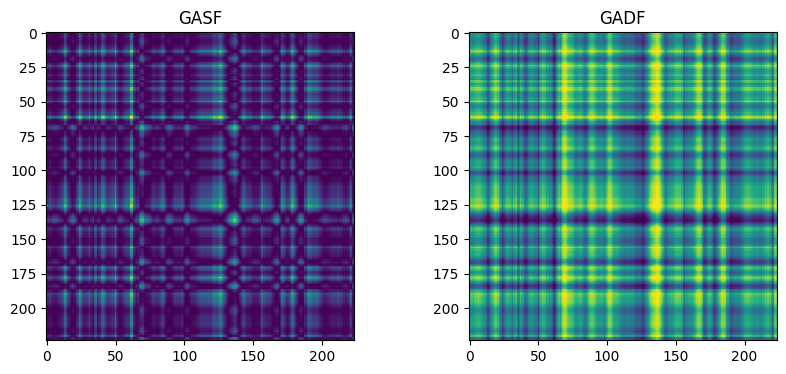

Label: 5


In [51]:
import matplotlib.pyplot as plt

inputs, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(inputs[0, 0])
plt.title("GASF")

plt.subplot(1, 2, 2)
plt.imshow(inputs[0, 1])
plt.title("GADF")

plt.show()

print("Label:", labels[0].item())

In [52]:
class FaultDiagnosis(nn.Module):

  def __init__(self):
    super().__init__()

    self.network = nn.Sequential(
        nn.Conv2d(in_channels=2, out_channels=32, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(0.3),

        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(0.3),

        nn.Conv2d(64, 128, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(128),
        nn.MaxPool2d(2, 2)
    )

    self.classifier = nn.Sequential(
        nn.AdaptiveAvgPool2d((1, 1)),

        nn.Flatten(),

        nn.Linear(in_features=128, out_features=64),
        nn.ReLU(),
        nn.Dropout(0.3),

        nn.Linear(in_features=64, out_features=32),
        nn.ReLU(),
        nn.Dropout(0.3),

        nn.Linear(in_features=32, out_features=10)
    )

  def forward(self, x):
    x = self.network(x)
    x = self.classifier(x)
    return x

In [112]:
model = FaultDiagnosis().to(device)

In [113]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

epochs = 100

In [114]:
print(optimizer)
print("LR:", optimizer.param_groups[0]["lr"])
print("Weight decay:", optimizer.param_groups[0]["weight_decay"])

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
LR: 0.001
Weight decay: 0.0001


In [115]:
inputs, labels = next(iter(train_loader))

print("Input shape:", inputs.shape)
print("Input min:", inputs.min().item())
print("Input max:", inputs.max().item())
print("Input mean:", inputs.mean().item())
print("Input std:", inputs.std().item())

print("Labels:", labels[:20])
print("Unique labels:", torch.unique(labels))

Input shape: torch.Size([32, 2, 224, 224])
Input min: 0.0
Input max: 1.0
Input mean: 0.2990730106830597
Input std: 0.2588813900947571
Labels: tensor([5, 8, 6, 2, 4, 9, 2, 1, 3, 7, 5, 4, 2, 3, 9, 4, 6, 1, 4, 8])
Unique labels: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [116]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Unique:", torch.unique(labels))
print("Counts:", torch.bincount(labels, minlength=10))

print("Image min:", images.min().item())
print("Image max:", images.max().item())
print("Image mean:", images.mean().item())
print("Image std:", images.std().item())

Images: torch.Size([32, 2, 224, 224])
Labels: torch.Size([32])
Unique: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Counts: tensor([3, 3, 3, 6, 2, 4, 1, 2, 5, 3])
Image min: 0.0
Image max: 1.0
Image mean: 0.2933122515678406
Image std: 0.2608950436115265


In [104]:
model = FaultDiagnosis().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss()

model.train()

for batch_idx, (inputs, labels) in enumerate(train_loader):

    inputs = inputs.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(inputs)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    if batch_idx < 10:
        predictions = outputs.argmax(dim=1)
        acc = (predictions == labels).float().mean() * 100

        print(
            f"Batch {batch_idx}: "
            f"Loss={loss.item():.4f}, "
            f"Acc={acc.item():.2f}%"
        )



Batch 0: Loss=2.3011, Acc=15.62%
Batch 1: Loss=2.3069, Acc=6.25%
Batch 2: Loss=2.2646, Acc=15.62%
Batch 3: Loss=2.2458, Acc=18.75%
Batch 4: Loss=2.1833, Acc=31.25%
Batch 5: Loss=2.2013, Acc=28.12%
Batch 6: Loss=2.2292, Acc=18.75%
Batch 7: Loss=2.2260, Acc=21.88%
Batch 8: Loss=2.1778, Acc=31.25%
Batch 9: Loss=2.1623, Acc=21.88%


In [102]:
from collections import Counter

print("TRAIN:", Counter(x[2] for x in train))
print("VAL:", Counter(x[2] for x in val))
print("TEST:", Counter(x[2] for x in test))

TRAIN: Counter({'OR_021': 662, 'IR_007': 661, 'OR_007': 661, 'B_007': 660, 'B_014': 660, 'B_021': 660, 'IR_014': 660, 'IR_021': 660, 'Normal': 660, 'OR_014': 660})
VAL: Counter({'IR_007': 69, 'B_007': 68, 'B_014': 68, 'B_021': 68, 'IR_014': 68, 'IR_021': 68, 'Normal': 68, 'OR_007': 68, 'OR_014': 68, 'OR_021': 68})
TEST: Counter({'IR_007': 69, 'B_007': 68, 'B_014': 68, 'B_021': 68, 'IR_014': 68, 'IR_021': 68, 'Normal': 68, 'OR_007': 68, 'OR_014': 68, 'OR_021': 68})


In [94]:
print("Model device:", next(model.parameters()).device)
print("Optimizer parameters:",
      sum(p.numel() for group in optimizer.param_groups for p in group["params"]))

Model device: cuda:0
Optimizer parameters: 104074


In [117]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0

In [96]:
first_weight = next(model.parameters()).detach().clone()

In [97]:
model.train()

inputs, labels = next(iter(train_loader))

inputs = inputs.to(device)
labels = labels.to(device)

optimizer.zero_grad()

outputs = model(inputs)
loss = criterion(outputs, labels)

loss.backward()
optimizer.step()

new_weight = next(model.parameters()).detach().clone()

print("Loss:", loss.item())
print("Weight changed:",
      not torch.equal(first_weight, new_weight))

Loss: 2.289214611053467
Weight changed: True


In [118]:
print("Training started")

for epoch in range(epochs):

  model.train()

  correct = 0
  total = 0
  running_loss = 0.0

  for inputs, labels in train_loader:
    inputs = inputs.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(inputs)

    loss = criterion(outputs, labels)

    loss.backward()
    
    optimizer.step()

    running_loss += loss.item()*inputs.size(0)
    _, predicted = torch.max(outputs, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

  train_loss = running_loss / total
  train_accuracy = 100*correct / total

  print("\nValidation started\n")

  model.eval()

  with torch.no_grad():
    correct = 0
    total = 0
    running_loss = 0.0

    for inputs, labels in val_loader:
      inputs = inputs.to(device)
      labels = labels.to(device)

      outputs = model(inputs)

      loss = criterion(outputs, labels)

      running_loss += loss.item()*inputs.size(0)
      _, predicted = torch.max(outputs, 1)

      total += labels.size(0)
      correct += (predicted == labels).sum().item()

    val_loss = running_loss / total
    val_accuracy = 100*correct / total

    if val_accuracy > best_val_accuracy:

      best_val_accuracy = val_accuracy

      torch.save(model.state_dict(),"3layer_wd4_best_weights_2d_mixed_model.pth")

      print(f"New best validation accuracy: {best_val_accuracy:.2f}%")

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] ")
    print(f"Train Loss: {train_loss:.4f} ")
    print(f"Train Acc: {train_accuracy:.2f}% ")
    print(f"Val Loss: {val_loss:.4f} ")
    print(f"Val Acc: {val_accuracy:.2f}%")

print("Training complete .....")

Training started

Validation started

New best validation accuracy: 63.14%
Epoch [1/100] 
Train Loss: 1.3273 
Train Acc: 51.86% 
Val Loss: 0.9932 
Val Acc: 63.14%

Validation started

New best validation accuracy: 78.56%
Epoch [2/100] 
Train Loss: 0.6858 
Train Acc: 76.01% 
Val Loss: 0.6010 
Val Acc: 78.56%

Validation started

New best validation accuracy: 81.64%
Epoch [3/100] 
Train Loss: 0.5464 
Train Acc: 81.28% 
Val Loss: 0.4821 
Val Acc: 81.64%

Validation started

Epoch [4/100] 
Train Loss: 0.4665 
Train Acc: 84.21% 
Val Loss: 0.7064 
Val Acc: 74.89%

Validation started

New best validation accuracy: 84.73%
Epoch [5/100] 
Train Loss: 0.3802 
Train Acc: 86.84% 
Val Loss: 0.3850 
Val Acc: 84.73%

Validation started

New best validation accuracy: 88.84%
Epoch [6/100] 
Train Loss: 0.3571 
Train Acc: 88.11% 
Val Loss: 0.3070 
Val Acc: 88.84%

Validation started

Epoch [7/100] 
Train Loss: 0.3190 
Train Acc: 89.17% 
Val Loss: 0.8775 
Val Acc: 75.92%

Validation started

New best valid

In [119]:
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Model device:", next(model.parameters()).device)

for name, param in model.named_parameters():
    if param.grad is not None:
        print(name, "gradient mean:", param.grad.abs().mean().item())
        break

Learning rate: 0.001
Model device: cuda:0
network.0.weight gradient mean: 0.002616293029859662


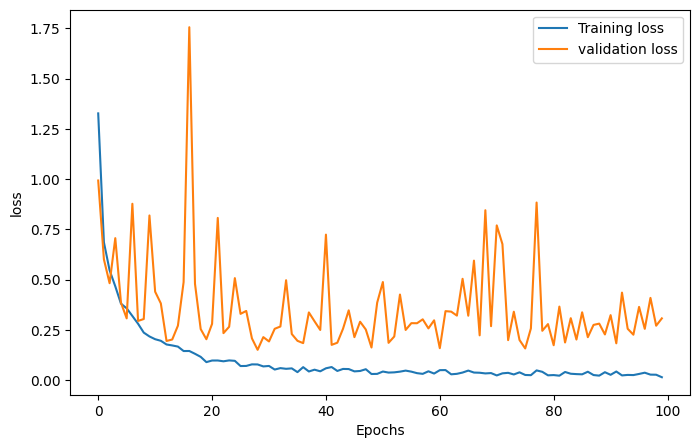

In [120]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='validation loss')

plt.xlabel('Epochs')
plt.ylabel('loss')

plt.legend()
plt.show()

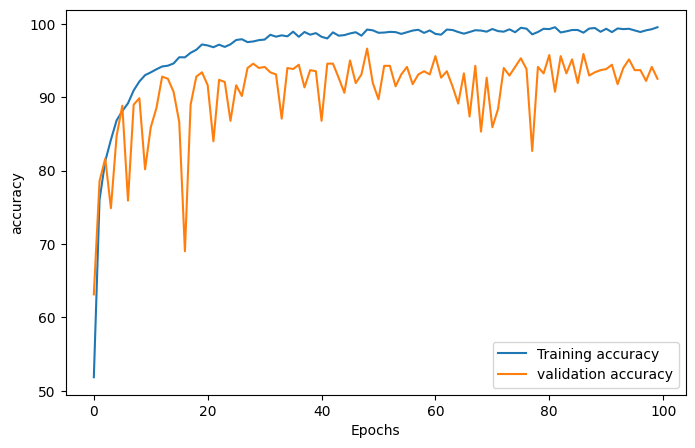

In [121]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label='Training accuracy')
plt.plot(val_accuracies, label='validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('accuracy')

plt.legend()
plt.show()

In [122]:
torch.save(model.state_dict(), '3layer_wd4_best_2d_mixed_model.pth')
print("Model saved for epoch 100")

Model saved for epoch 100


In [123]:
# model.load_state_dict(
#     torch.load(
#         r"C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\2D CNN\notebooks\best_2d_mixed_model.pth",
#         weights_only=True
#     )
# )

# model = model.to(device)

best_model = FaultDiagnosis().to(device)

best_model.load_state_dict(
    torch.load(
        r"C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\2D_CNN\notebooks\3layer_wd4_best_weights_2d_mixed_model.pth",
        weights_only=True
    )
)

<All keys matched successfully>

In [124]:
total_difference = 0.0
max_difference = 0.0

for p1, p2 in zip(model.parameters(), best_model.parameters()):
    diff = (p1 - p2).abs()

    total_difference += diff.sum().item()
    max_difference = max(max_difference, diff.max().item())

print("Total weight difference:", total_difference)
print("Maximum weight difference:", max_difference)

Total weight difference: 4073.948511481285
Maximum weight difference: 0.28878289461135864


In [127]:
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Model device:", next(best_model.parameters()).device)

for name, param in best_model.named_parameters():
    if param.grad is not None:
        print(name, "gradient mean:", param.grad.abs().mean().item())
        break

Learning rate: 0.001
Model device: cuda:0


In [128]:
print("Training started")

best_model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():

  for inputs, labels in train_loader:
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = best_model(inputs)

    _, predicted = torch.max(outputs, 1)

    test_total += labels.size(0)
    test_correct += (predicted == labels).sum().item()

  test_accuracy = 100*test_correct / test_total
  print(f"Training accuracy : {test_accuracy:.2f}%")

Training started
Training accuracy : 99.95%


In [129]:
print("Validation started")

best_model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():

  for inputs, labels in val_loader:
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = best_model(inputs)

    _, predicted = torch.max(outputs, 1)

    test_total += labels.size(0)
    test_correct += (predicted == labels).sum().item()

  test_accuracy = 100*test_correct / test_total
  print(f"Validation accuracy : {test_accuracy:.2f}%")

Validation started
Validation accuracy : 96.62%


In [131]:
print("Testing started")

best_model.eval()

test_correct = 0
test_total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

  for inputs, labels in test_loader:
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = best_model(inputs)

    _, predicted = torch.max(outputs, 1)

    test_total += labels.size(0)
    test_correct += (predicted == labels).sum().item()

    all_labels.extend(labels.cpu().numpy())
    all_predictions.extend(predicted.cpu().numpy())


  test_accuracy = 100*test_correct / test_total
  print(f"Test accuracy : {test_accuracy:.2f}%")

  all_labels = np.array(all_labels)

  all_predictions = np.array(all_predictions)

  cm = confusion_matrix(
    all_labels,
    all_predictions
  )

  print(cm)

Testing started
Test accuracy : 94.42%
[[59  5  2  1  0  0  0  0  1  0]
 [ 4 56  4  2  1  0  0  0  1  0]
 [ 3  2 59  1  1  0  0  0  2  0]
 [ 0  3  1 65  0  0  0  0  0  0]
 [ 0  2  0  0 66  0  0  0  0  0]
 [ 0  2  0  0  0 66  0  0  0  0]
 [ 0  0  0  0  0  0 68  0  0  0]
 [ 0  0  0  0  0  0  0 68  0  0]
 [ 0  0  0  0  0  0  0  0 68  0]
 [ 0  0  0  0  0  0  0  0  0 68]]


In [136]:
from sklearn.metrics import classification_report

class_names = [
    "B_007",
    "B_014",
    "B_021",
    "IR_007",
    "IR_014",
    "IR_021",
    "Normal",
    "OR_007",
    "OR_014",
    "OR_021",
]

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

       B_007     0.8939    0.8676    0.8806        68
       B_014     0.8000    0.8235    0.8116        68
       B_021     0.8939    0.8676    0.8806        68
      IR_007     0.9420    0.9420    0.9420        69
      IR_014     0.9706    0.9706    0.9706        68
      IR_021     1.0000    0.9706    0.9851        68
      Normal     1.0000    1.0000    1.0000        68
      OR_007     1.0000    1.0000    1.0000        68
      OR_014     0.9444    1.0000    0.9714        68
      OR_021     1.0000    1.0000    1.0000        68

    accuracy                         0.9442       681
   macro avg     0.9445    0.9442    0.9442       681
weighted avg     0.9445    0.9442    0.9442       681

